In [ ]:
!unzip "/content/archive (5).zip"

Archive:  /content/archive (5).zip
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_1.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_10.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_100.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_101.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_102.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_103.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_104.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_105.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_106.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_107.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_108.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_109.jpg  
  inflating: PLD_3_Classes_256/Testing/Early_Blight/Early_Blight_11.

In [ ]:
# STEP 1: Data Preparation
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [ ]:

# Set dataset path (change if needed)
data_dir = "/content/PLD_3_Classes_256"



In [ ]:
# Transformations for training data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # make all images same size
    transforms.RandomHorizontalFlip(),  # flip images randomly
    transforms.RandomRotation(20),      # rotate images
    transforms.ToTensor()               # convert image to numbers
])

# Transformations for validation and testing
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load datasets from folders
train_data = datasets.ImageFolder(os.path.join(data_dir, "/content/PLD_3_Classes_256/Training"), transform=train_transform)
val_data = datasets.ImageFolder(os.path.join(data_dir, "/content/PLD_3_Classes_256/Validation"), transform=test_transform)
test_data = datasets.ImageFolder(os.path.join(data_dir, "/content/PLD_3_Classes_256/Testing"), transform=test_transform)

# Create data loaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# Show dataset details
print("Classes:", train_data.classes)
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Testing images:", len(test_data))

Classes: ['Early_Blight', 'Healthy', 'Late_Blight']
Training images: 3251
Validation images: 416
Testing images: 405


In [ ]:
# STEP 2: Model Definition

import torch
import torch.nn as nn
from torchvision import models

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load pretrained MobileNetV2
model = models.mobilenet_v2(pretrained=True)

# Freeze all layers (no training for base model)
for param in model.parameters():
    param.requires_grad = False

# Change final layer for 3 classes
model.classifier[1] = nn.Linear(model.last_channel, 3)

# Move model to device
model = model.to(device)

# Print model summary
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 165MB/s]


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
# STEP 3: Training Setup

import torch.nn as nn
import torch.optim as optim

# Loss function (for classification)
criterion = nn.CrossEntropyLoss()

# Optimizer (updates model weights)
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001)

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, epochs=10):

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # ---------------- TRAIN ----------------
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # ---------------- VALIDATION ----------------
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        # store
        train_losses.append(train_loss / len(train_loader))
        val_losses.append(val_loss / len(val_loader))
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_acc:.4f}")
        print("--------------------------------------------------")

    return train_losses, val_losses, train_accs, val_accs

In [ ]:
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=0.001)

train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, optimizer, epochs=10
)

Epoch 1/10
Train Loss: 0.4037 | Train Acc: 0.8677
Val Loss: 0.2406 | Val Acc: 0.9303
--------------------------------------------------
Epoch 2/10
Train Loss: 0.2286 | Train Acc: 0.9289
Val Loss: 0.2856 | Val Acc: 0.8798
--------------------------------------------------
Epoch 3/10
Train Loss: 0.1966 | Train Acc: 0.9329
Val Loss: 0.2077 | Val Acc: 0.9231
--------------------------------------------------
Epoch 4/10
Train Loss: 0.1837 | Train Acc: 0.9348
Val Loss: 0.1982 | Val Acc: 0.9255
--------------------------------------------------
Epoch 5/10
Train Loss: 0.1624 | Train Acc: 0.9477
Val Loss: 0.2777 | Val Acc: 0.8822
--------------------------------------------------
Epoch 6/10
Train Loss: 0.1625 | Train Acc: 0.9440
Val Loss: 0.2045 | Val Acc: 0.9231
--------------------------------------------------
Epoch 7/10
Train Loss: 0.1534 | Train Acc: 0.9477
Val Loss: 0.1564 | Val Acc: 0.9351
--------------------------------------------------
Epoch 8/10
Train Loss: 0.1571 | Train Acc: 0.949

In [ ]:
print("Starting Fine-Tuning...")

# Unfreeze last layers
for param in model.features[-4:].parameters():
    param.requires_grad = True

optimizer_ft = torch.optim.Adam([
    {'params': model.classifier.parameters(), 'lr': 1e-4},
    {'params': model.features[-4:].parameters(), 'lr': 1e-5}
])

scheduler = torch.optim.lr_scheduler.StepLR(optimizer_ft, step_size=3, gamma=0.1)

ft_losses, ft_val_losses, ft_accs, ft_val_accs = train_model(
    model, train_loader, val_loader, optimizer_ft, epochs=5
)

scheduler.step()

Starting Fine-Tuning...
Epoch 1/5
Train Loss: 0.1358 | Train Acc: 0.9517
Val Loss: 0.1418 | Val Acc: 0.9447
--------------------------------------------------
Epoch 2/5
Train Loss: 0.1202 | Train Acc: 0.9576
Val Loss: 0.1297 | Val Acc: 0.9471
--------------------------------------------------
Epoch 3/5
Train Loss: 0.1040 | Train Acc: 0.9643
Val Loss: 0.1219 | Val Acc: 0.9495
--------------------------------------------------
Epoch 4/5
Train Loss: 0.0998 | Train Acc: 0.9686
Val Loss: 0.1199 | Val Acc: 0.9495
--------------------------------------------------
Epoch 5/5
Train Loss: 0.0979 | Train Acc: 0.9680
Val Loss: 0.1159 | Val Acc: 0.9543
--------------------------------------------------


In [ ]:
def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"\n✅ Test Accuracy: {accuracy*100:.2f}%")

    return all_preds, all_labels

In [ ]:
all_preds, all_labels = evaluate_model(model, test_loader)


✅ Test Accuracy: 96.79%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def show_predictions(model, loader, class_names, num_images=6):
    model.eval()

    # Get dataset directly
    dataset = loader.dataset

    # Random indices
    indices = torch.randperm(len(dataset))[:num_images]

    images = []
    labels = []

    for idx in indices:
        img, label = dataset[idx]
        images.append(img)
        labels.append(label)

    images = torch.stack(images).to(device)
    labels = torch.tensor(labels)

    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

    images = images.cpu().numpy()

    plt.figure(figsize=(12,6))

    for i in range(num_images):
        plt.subplot(2, 3, i+1)

        img = np.transpose(images[i], (1,2,0))

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i].item()]
        confidence = probs[i][preds[i]].item()

        # Color logic
        if pred_label == true_label:
            title = f"✔ {pred_label}\n({confidence:.2f})"
            color = 'green'
        else:
            title = f"✘ {pred_label} | {true_label}\n({confidence:.2f})"
            color = 'red'

        plt.imshow(img)
        plt.title(title, color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

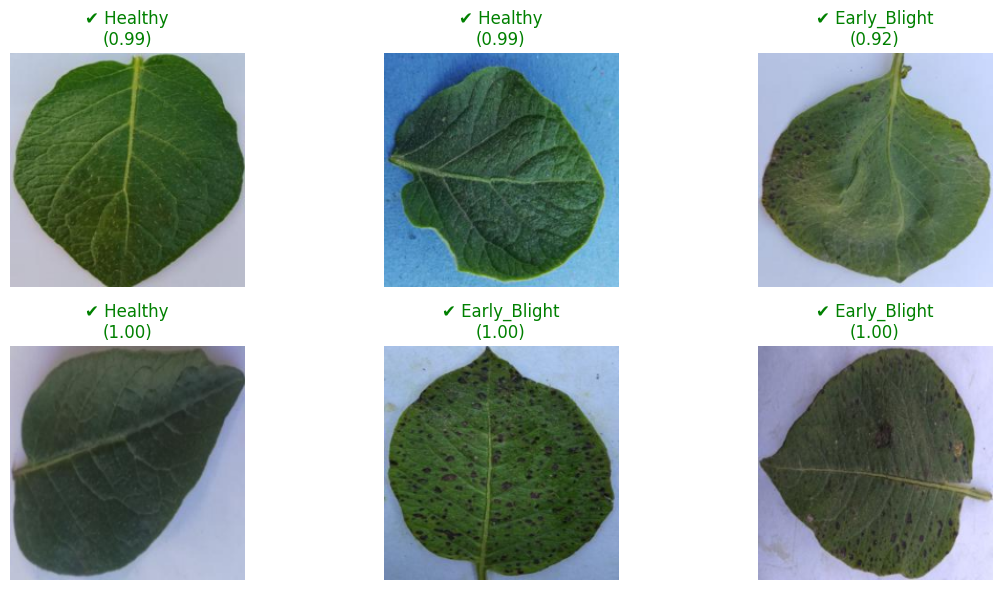

In [ ]:
class_names = train_data.classes
show_predictions(model, test_loader, class_names)

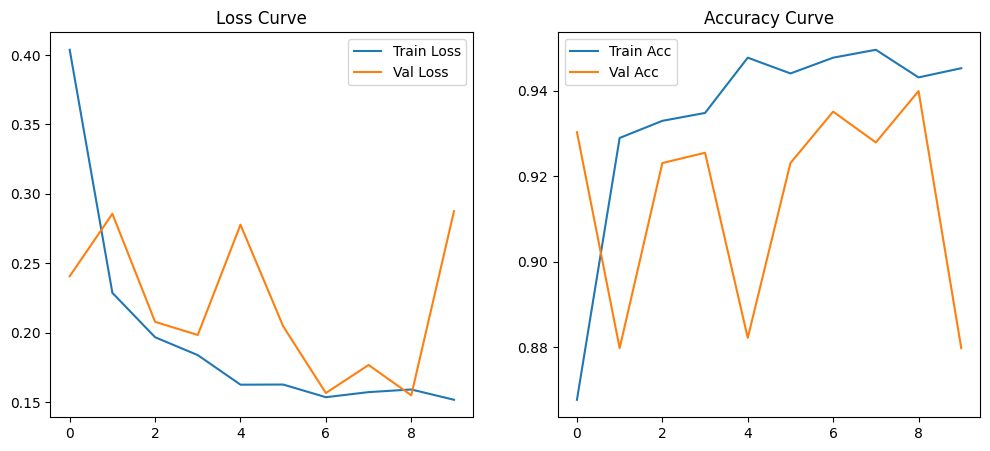

In [ ]:
def plot_curves(train_losses, val_losses, train_accs, val_accs):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.legend()
    plt.title("Accuracy Curve")

    plt.show()

plot_curves(train_losses, val_losses, train_accs, val_accs)

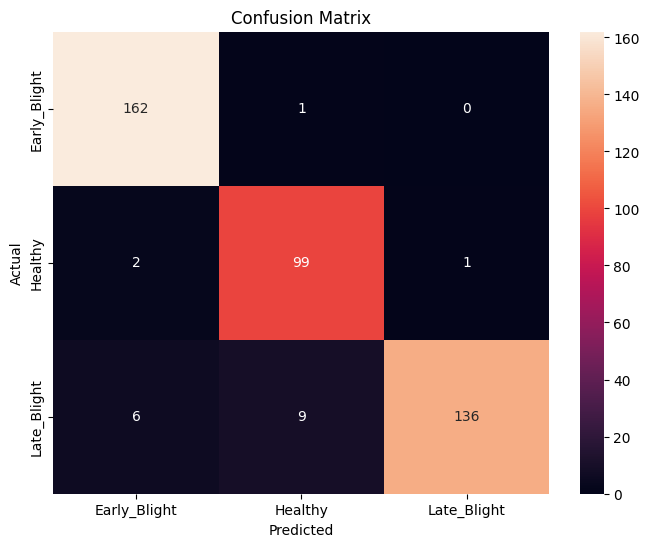

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(model, loader, class_names):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

# IMPORTANT: use actual class names
class_names = train_data.classes

plot_confusion_matrix(model, val_loader, class_names)

In [ ]:
torch.save(model.state_dict(), "plant_disease_model.pth")

In [ ]:
model.load_state_dict(torch.load("plant_disease_model.pth", map_location=device))

<All keys matched successfully>

In [ ]:
class_names = train_data.classes

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import gradio as gr

# -------------------------------
# DEVICE
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------
# LOAD MODEL (SAME STRUCTURE)
# -------------------------------
model = models.mobilenet_v2(pretrained=False)
model.classifier[1] = nn.Linear(model.last_channel, 3)

# Load trained weights
model.load_state_dict(torch.load("plant_disease_model.pth", map_location=device))

model = model.to(device)
model.eval()

# MUST match training dataset
class_names = train_data.classes   # ✅ Correct way

# If running separately, manually paste:
# class_names = ['Early Blight', 'Late Blight', 'Healthy']


# TRANSFORM (same as test)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_image(image):

    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)[0]

    result = {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    return result

# -------------------------------
# GRADIO UI
# -------------------------------
interface = gr.Interface(
    fn=predict_image,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="🌿 Plant Disease Detection",
    description="Upload a leaf image to detect disease using MobileNetV2"
)

# -------------------------------
# LAUNCH
# -------------------------------
interface.launch()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f0d24fe9956198faa7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
